Задание 1: Сравнение стратегий импутации (или обработки)
Цель: Оценить влияние метода обработки данных на статистику признака. Инструкция:

Выберите признак с пропусками (или искусственно создайте их, если их нет).
Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
Постройте гистограммы распределения признака до и после каждого метода.
Рассчитайте, как изменилось среднее и стандартное отклонение.
Вывод: Какой метод меньше исказил исходное распределение?
Подсказка: Используйте df.describe() до и после операций. Для продвинутых: попробуйте IterativeImputer из sklearn.impute.

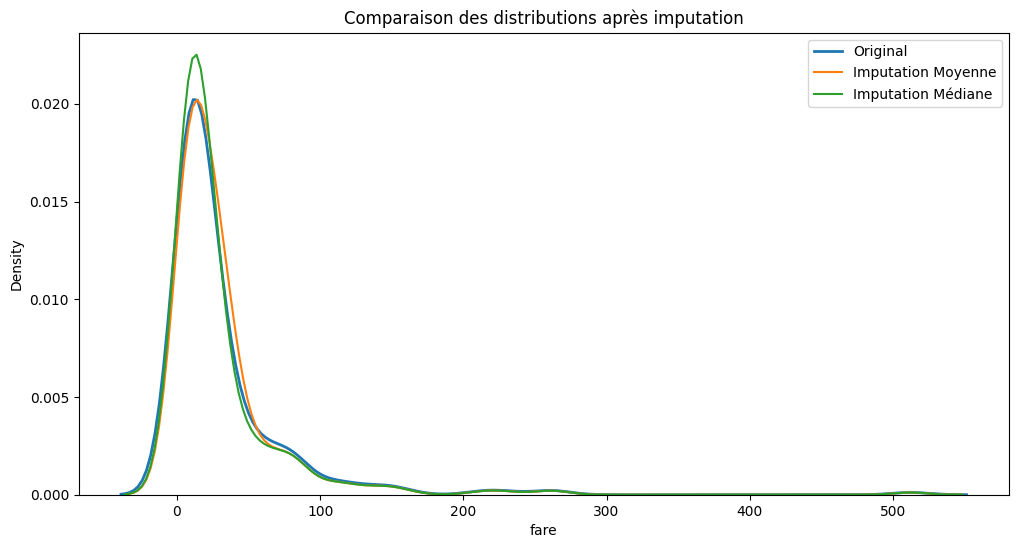

Original:
 count    795.000000
mean      31.767384
std       49.442174
min        0.000000
25%        7.895800
50%       14.454200
75%       30.847900
max      512.329200
Name: fare, dtype: float64

Imputation Moyenne:
 count    891.000000
mean      31.767384
std       46.699562
min        0.000000
25%        8.050000
50%       16.100000
75%       31.767384
max      512.329200
Name: fare, dtype: float64

Imputation Médiane:
 count    891.000000
mean      29.901990
std       47.007422
min        0.000000
25%        8.050000
50%       14.454200
75%       28.606250
max      512.329200
Name: fare, dtype: float64


In [1]:
# --- TÂCHE 1 : IMPUTATION DU TARIF (FARE) --- вариант 8

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger Titanic
df = sns.load_dataset("titanic")

# Garder uniquement les colonnes utiles
df = df[['fare', 'survived', 'class', 'age']]

# Créer artificiellement 10% de valeurs manquantes dans Fare
np.random.seed(42)
mask = np.random.choice([True, False], size=len(df), p=[0.1, 0.9])
df.loc[mask, 'fare'] = np.nan

# Sauvegarde de la distribution originale
original = df['fare'].dropna()

# Méthode 1 : Imputation par la moyenne
df_mean = df.copy()
df_mean['fare'] = df_mean['fare'].fillna(df_mean['fare'].mean())

# Méthode 2 : Imputation par la médiane
df_median = df.copy()
df_median['fare'] = df_median['fare'].fillna(df_median['fare'].median())

# --- Visualisation ---
plt.figure(figsize=(12,6))
sns.kdeplot(original, label="Original", linewidth=2)
sns.kdeplot(df_mean['fare'], label="Imputation Moyenne")
sns.kdeplot(df_median['fare'], label="Imputation Médiane")
plt.title("Comparaison des distributions après imputation")
plt.legend()
plt.show()

# --- Statistiques ---
print("Original:\n", original.describe())
print("\nImputation Moyenne:\n", df_mean['fare'].describe())
print("\nImputation Médiane:\n", df_median['fare'].describe())


Задание 2: Детекция и визуализация выбросов
Цель: Научиться находить и аргументированно удалять аномалии. Инструкция:

Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
Найдите выбросы методом IQR и методом Z-Score.
Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
Посчитайте процент выбросов от общего числа данных.
Вывод: Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?

Outliers IQR : 13.02%
Outliers Z-score : 2.24%


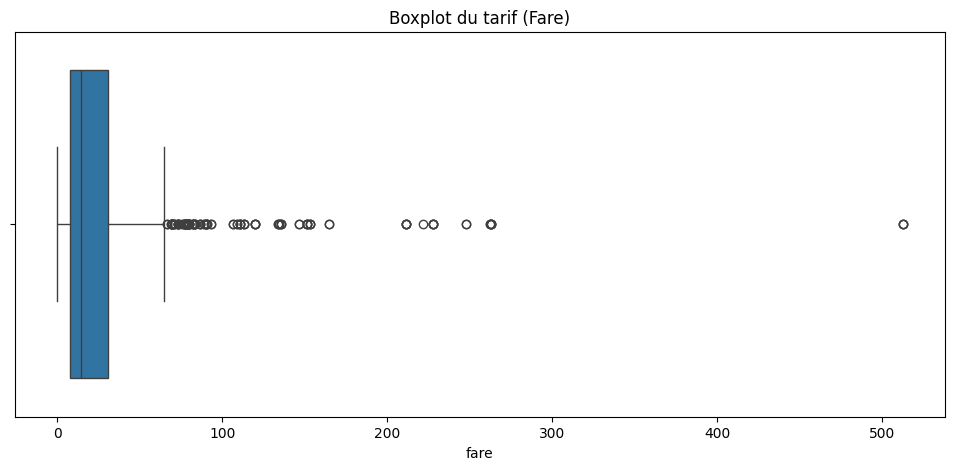

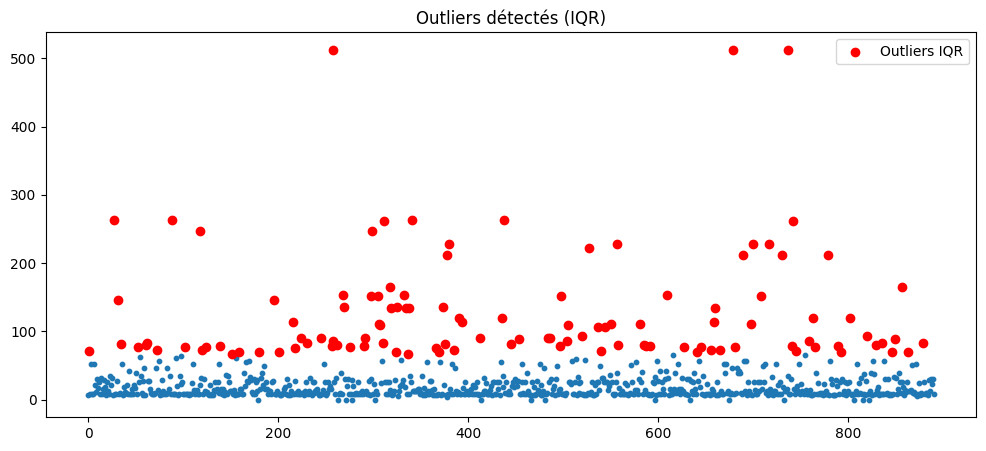

In [2]:
# --- TÂCHE 2 : DÉTECTION DES OUTLIERS ---

from scipy import stats

df2 = sns.load_dataset("titanic")[['fare']].dropna()

# Méthode IQR
Q1 = df2['fare'].quantile(0.25)
Q3 = df2['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df2[(df2['fare'] < lower) | (df2['fare'] > upper)]

# Méthode Z-score
df2['zscore'] = stats.zscore(df2['fare'])
outliers_z = df2[df2['zscore'].abs() > 3]

# Pourcentage d'outliers
pct_iqr = len(outliers_iqr) / len(df2) * 100
pct_z = len(outliers_z) / len(df2) * 100

print(f"Outliers IQR : {pct_iqr:.2f}%")
print(f"Outliers Z-score : {pct_z:.2f}%")

# --- Visualisation ---
plt.figure(figsize=(12,5))
sns.boxplot(x=df2['fare'])
plt.title("Boxplot du tarif (Fare)")
plt.show()

plt.figure(figsize=(12,5))
plt.scatter(range(len(df2)), df2['fare'], s=10)
plt.scatter(outliers_iqr.index, outliers_iqr['fare'], color='red', label="Outliers IQR")
plt.legend()
plt.title("Outliers détectés (IQR)")
plt.show()


Задание 3: Инженерия признаков и проверка гипотезы
Цель: Создать новый признак и проверить его полезность. Инструкция:

Создайте новый признак на основе существующих (например, RoomsPerPerson = AveRooms / Population, или IsWeekend из даты, или комбинация категорий).
Постройте корреляционную матрицу с включением нового признака.
Постройте график зависимости нового признака от целевой переменной.
Вывод: Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?
Подсказка: Хороший признак должен иметь физический смысл. Избегайте "мусорных" комбинаций..

fare            0.268189
age            -0.077221
survived        1.000000
fare_per_age    0.138080
Name: survived, dtype: float64


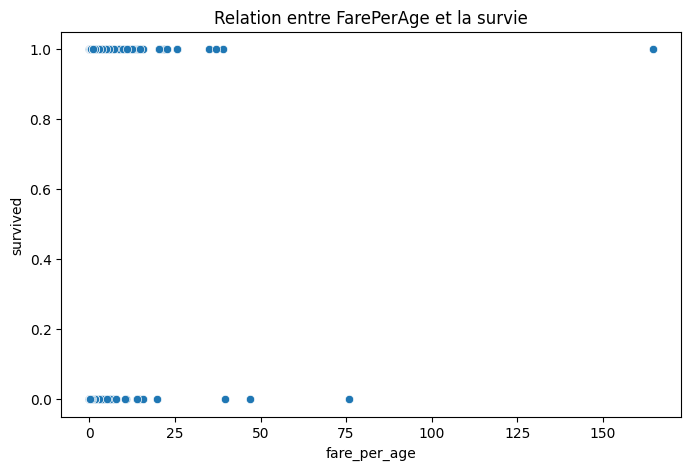

In [3]:
# --- TÂCHE 3 : FEATURE ENGINEERING ---

df3 = sns.load_dataset("titanic")[['fare', 'age', 'survived']].dropna()

# Nouvelle caractéristique
df3['fare_per_age'] = df3['fare'] / df3['age']

# Corrélation
corr_matrix = df3.corr()
print(corr_matrix['survived'])

# Visualisation
plt.figure(figsize=(8,5))
sns.scatterplot(x=df3['fare_per_age'], y=df3['survived'])
plt.title("Relation entre FarePerAge et la survie")
plt.show()
